# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Minahil Faisal`  
**SFU ID:** `301654970`  
**Date:** `25 June, 2026`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [2]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [3]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [4]:
# Missing values
df_ab.isnull().sum()


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


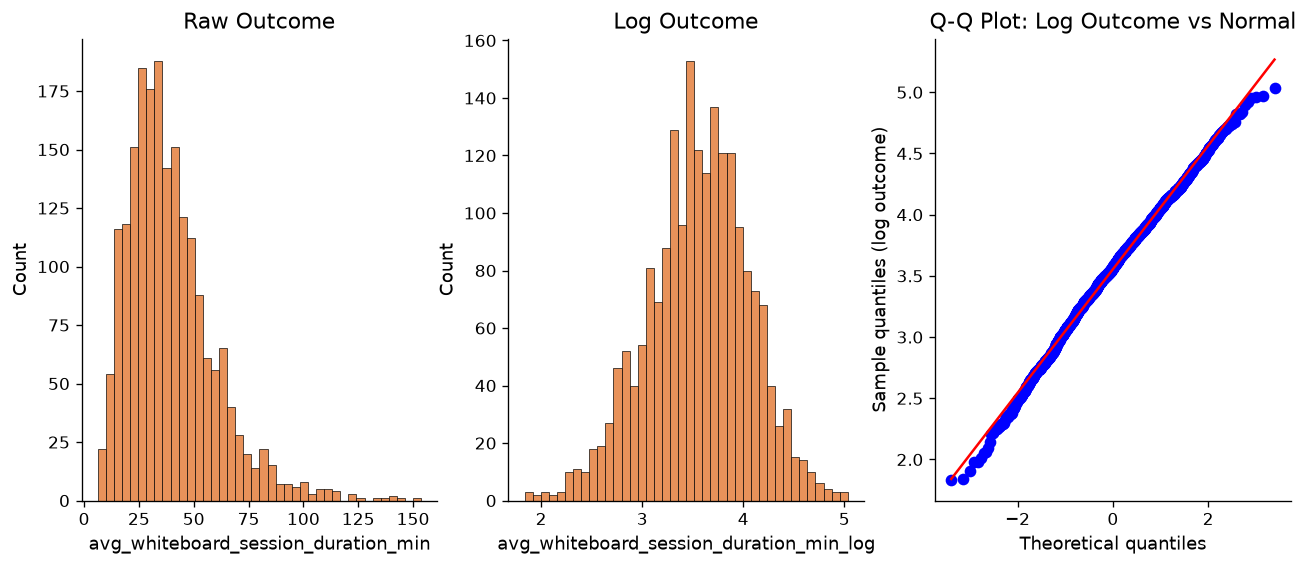

Skewness of raw outcome: 1.38
Skewness of log-transformed outcome: -0.21


In [5]:
# BEGIN
#     Load target outcome variable
wb_session_duration = df_ab['avg_whiteboard_session_duration_min']

#     // 1. Normality & Transformation Visualizations
#     Initialize three-panel visual layout
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
    
#     Draw histogram of raw outcome distribution
ax[0].hist(wb_session_duration, bins=40, color=ACCENT, edgecolor='black', linewidth=0.4)
ax[0].set_title('Raw Outcome')
ax[0].set_xlabel('avg_whiteboard_session_duration_min')
ax[0].set_ylabel('Count')

#     Transform outcome variable using natural logarithm
wb_session_duration_log = np.log(wb_session_duration)
df_ab['avg_whiteboard_session_duration_min_log'] = wb_session_duration_log

#     Draw histogram of log-transformed outcome distribution
ax[1].hist(wb_session_duration_log, bins=40, color=ACCENT, edgecolor='black', linewidth=0.4)
ax[1].set_title('Log Outcome')
ax[1].set_xlabel('avg_whiteboard_session_duration_min_log')
ax[1].set_ylabel('Count')

#     Draw Q-Q plot comparing log-transformed distribution to a normal distribution
stats.probplot(wb_session_duration_log, dist='norm', plot=ax[2])
ax[2].set_title('Q-Q Plot: Log Outcome vs Normal')
ax[2].set_xlabel('Theoretical quantiles')
ax[2].set_ylabel('Sample quantiles (log outcome)')

#     Render visualizations
plt.show()

#     // 2. Statistical Diagnostics
#     Compute and output skewness for both raw and log-transformed distributions
skew_raw = stats.skew(wb_session_duration)
skew_log = stats.skew(wb_session_duration_log)

print(f'Skewness of raw outcome: {skew_raw:.2f}')
print(f'Skewness of log-transformed outcome: {skew_log:.2f}')

# END

**✏️ Your interpretation (A1.1):**

The log-tranformed outcome is more normally distributed as we can see from the above plots. The second graph shows us the histogram from the log transformed data, and we can see that it has more of a bell shape than the raw outcome, which is right-skewed in the first graph. The Q-Q plot supports this conclusion. We can see the theoretical quantiles plotted on the graph as the red colored straight line with a slope of 0.45, and our actual log transformed data points falls on that line. This shows us that our data matches the normal distribution. Hence, we will use the log outcome in our models.


#### A1.2 — Examine the confounders

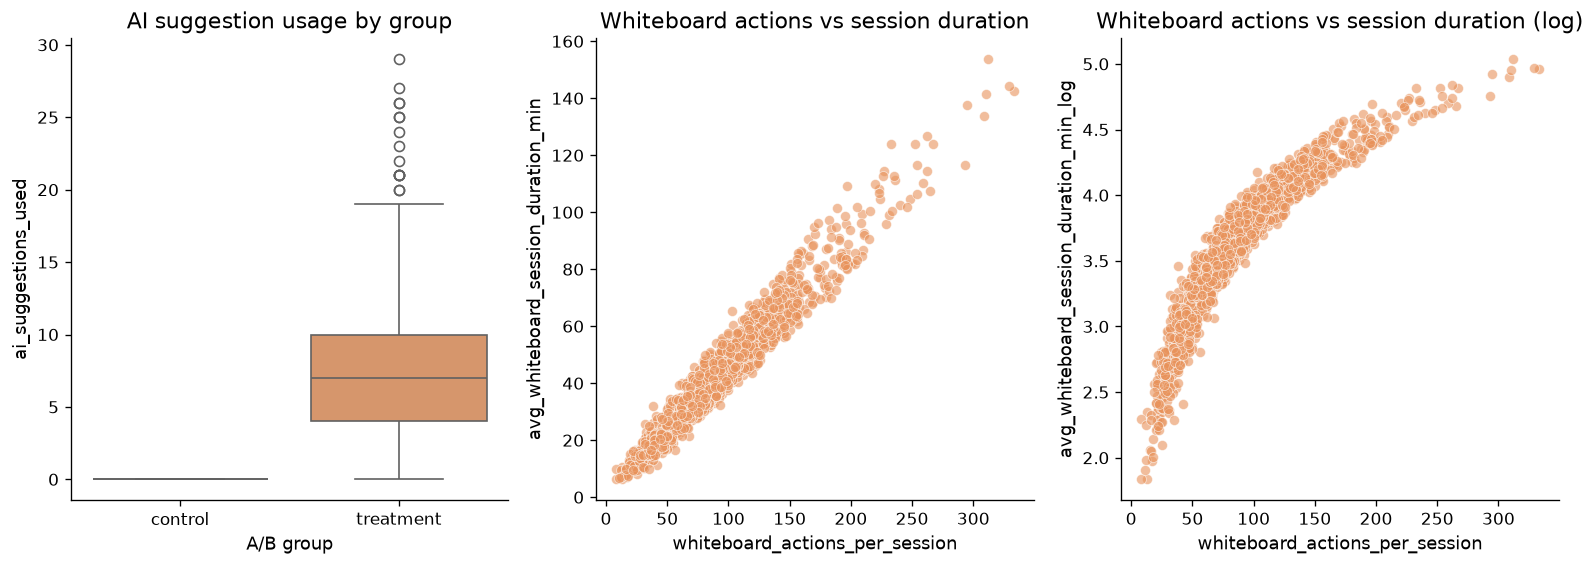

Correlation with raw outcome: 0.974
Correlation with log outcome: 0.914

Statistics for AI suggestion usage by A/B group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [6]:
# // Define the analytical pipeline
# BEGIN
#     Load AB testing dataset

#     // 1. Visual Exploratory Data Analysis
#     Initialize side-by-side visualization layouts
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    
#     Draw boxplot comparison of AI suggestion usage across experimental groups
#     Draw scatter plot comparing whiteboard activity density against session durations
#     Optimize layout and display visualizations
sns.boxplot(data=df_ab, x='ab_group', y='ai_suggestions_used', color=ACCENT, ax=ax[0])
ax[0].set_title('AI suggestion usage by group')
ax[0].set_xlabel('A/B group')
ax[0].set_ylabel('ai_suggestions_used')

sns.scatterplot(
    data=df_ab,
    x='whiteboard_actions_per_session',
    y='avg_whiteboard_session_duration_min',
    alpha=0.6,
    color=ACCENT,
    ax=ax[1],
    legend=True
)
ax[1].set_title('Whiteboard actions vs session duration')
ax[1].set_xlabel('whiteboard_actions_per_session')
ax[1].set_ylabel('avg_whiteboard_session_duration_min')

sns.scatterplot(
    data=df_ab,
    x='whiteboard_actions_per_session',
    y=wb_session_duration_log,
    alpha=0.6,
    color=ACCENT,
    ax=ax[2],
    legend=True
)
ax[2].set_title('Whiteboard actions vs session duration (log)')
ax[2].set_xlabel('whiteboard_actions_per_session')
ax[2].set_ylabel('avg_whiteboard_session_duration_min_log')

plt.show()

#     // 2. Statistical Analysis
#     Calculate and print the correlation between whiteboard activity and session duration
corr_raw = df_ab['whiteboard_actions_per_session'].corr(df_ab['avg_whiteboard_session_duration_min'])
corr_log = df_ab['whiteboard_actions_per_session'].corr(wb_session_duration_log)
print(f'Correlation with raw outcome: {corr_raw:.3f}')
print(f'Correlation with log outcome: {corr_log:.3f}\n')

#     Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
print('Statistics for AI suggestion usage by A/B group:')
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))
# END

**✏️ Your interpretation (A1.2):**

We can see from the box plot that there were no AI suggestions used for the control group, however, the treatment group did use AI suggestions. This is inline with the experiment conducted, that only the treatment group would have access to AI features, and the control group would not. 

The correlation between `whiteboard_actions_per_session` and the outcome suggests that both control groups end up having more whiteboard actions, the longer they use the whiteboard in a session, and vice versa. It does not tell us anything when it comes to AI usage, (did AI usage increase session time, etc?) and has no direct corelation to what we are investigating. And this is because both a/b groups have rougly the same pattern of whiteboard actions across session durations. Hence, we will not include this variable in our model as it can lead to wrong analysis and results.


#### A1.3 — Predictor distributions and relationships with outcome

account_age_days correlation with log outcome: -0.035

prior_whiteboard_sessions correlation with log outcome: 0.182

num_collaborators correlation with log outcome: 0.107

templates_used correlation with log outcome: 0.160



Text(0.5, 0.98, 'Predictor Distributions and Relationships with Log Session Durations')

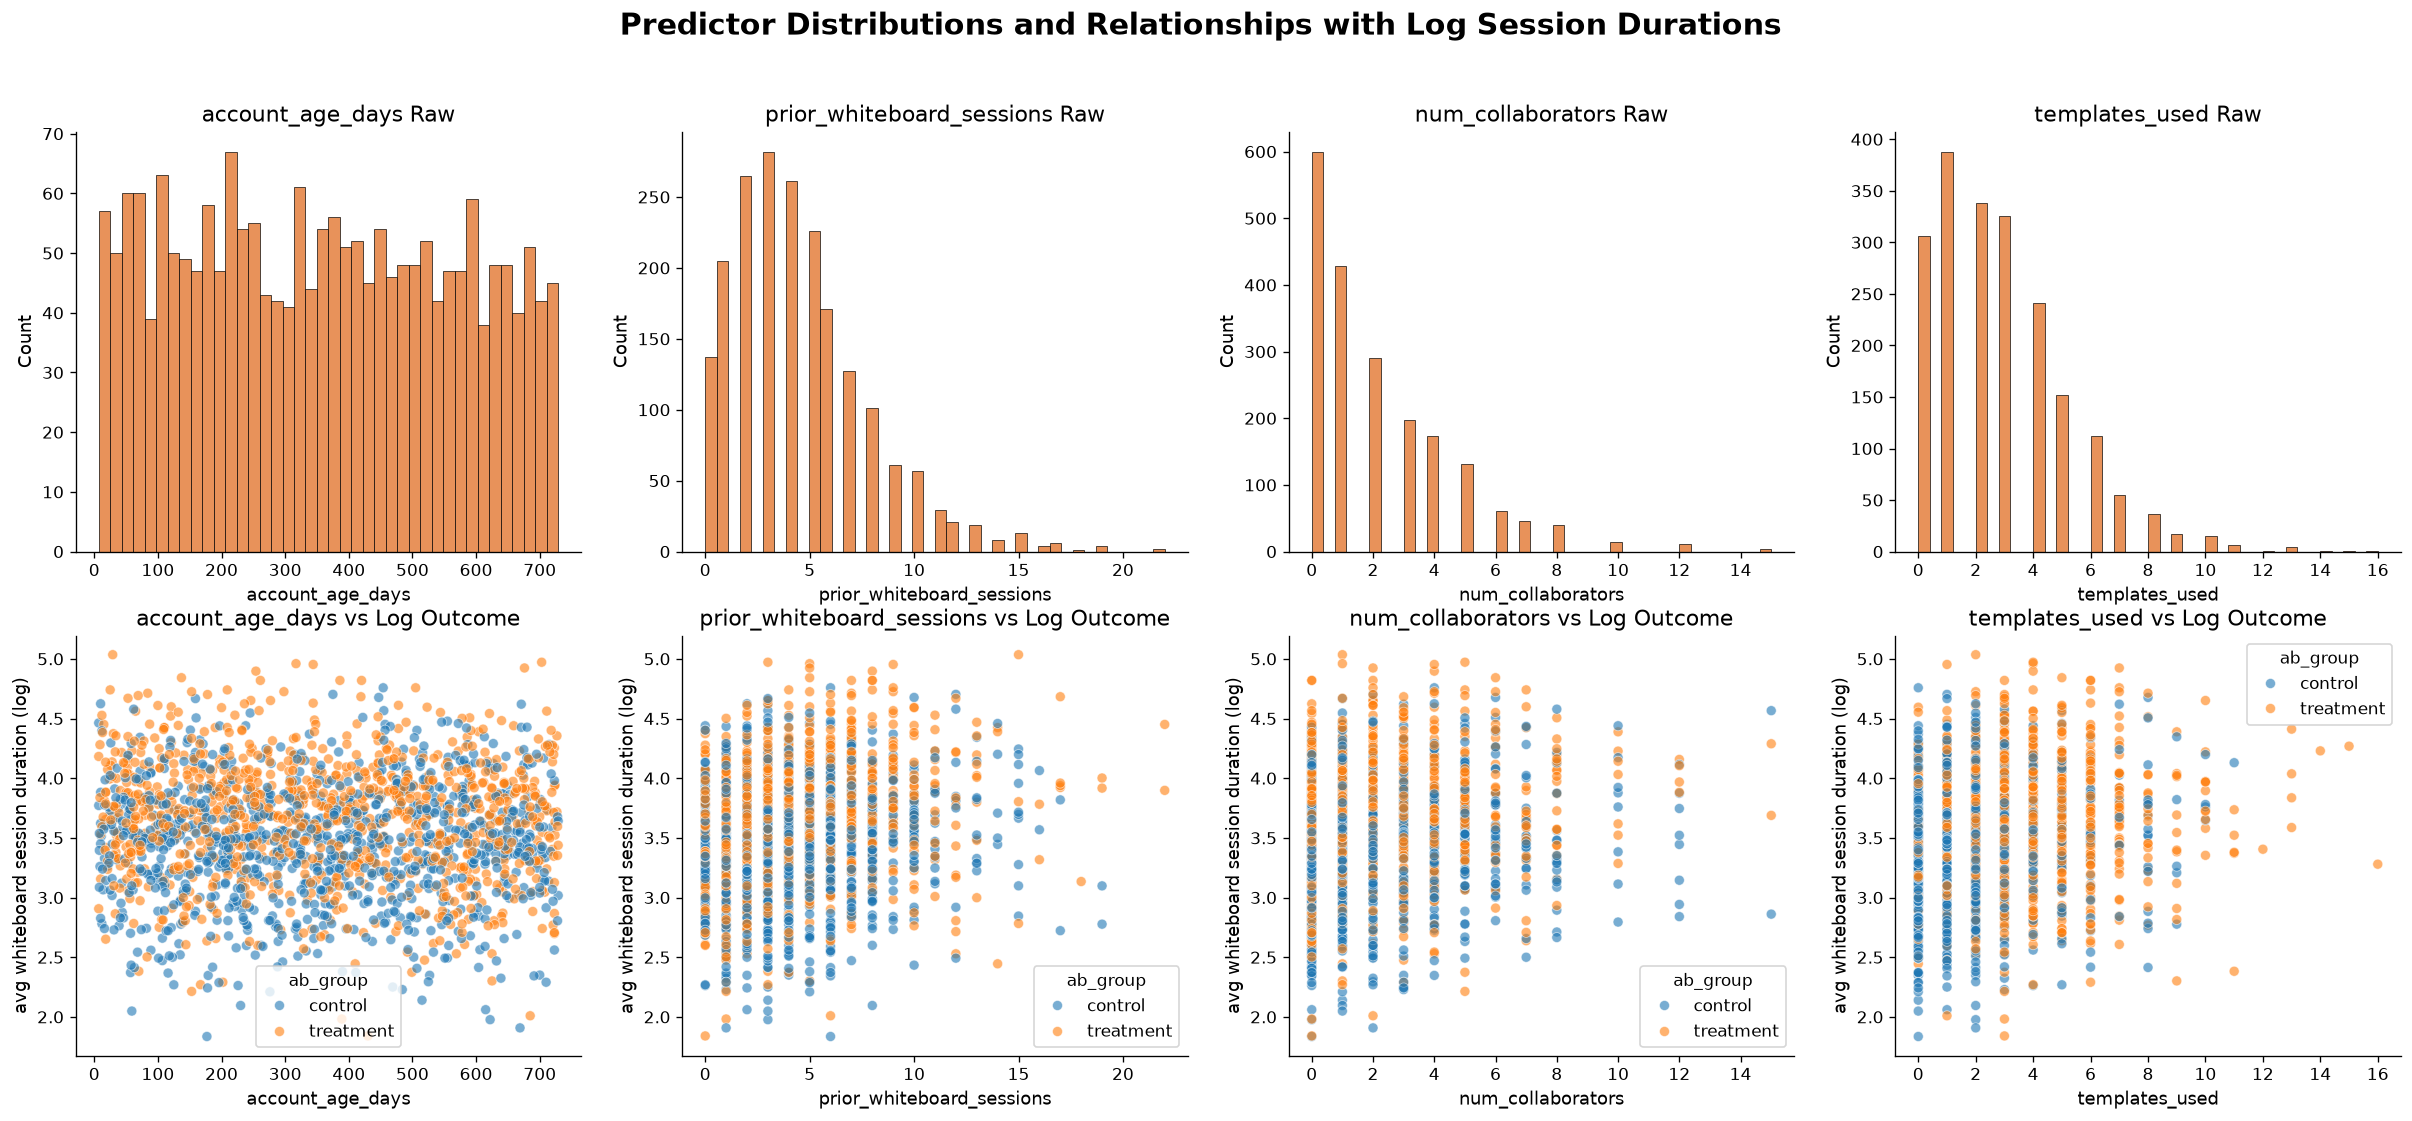

In [7]:
# BEGIN
#     Define list of numerical predictor variables
#     Compute log-transformed outcome variable
predictors = ['account_age_days', 'prior_whiteboard_sessions', 'num_collaborators', 'templates_used']
N = len(predictors) # 4 predictors to analyze

#     Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)
fig, ax = plt.subplots(2, N, figsize=(25, 10))

#     FOR each predictor variable:
#         // Top row: Univariate Analysis
#         Draw histogram to show distribution of the predictor
#BEGIN[ChatGPT][https://chatgpt.com/s/t_6a3db10b257c8191a26c60b358cb89c0]
# ["help me fix this loop in python for predictor in predictors: # Draw histogram
# of raw outcome distribution ax[i].hist(df_ab[predictor], bins=40, color=ACCENT, 
# edgecolor='black', linewidth=0.4) ax[i].set_title(f'{predictor} Raw Outcome') 
# ax[i].set_xlabel(predictor) ax[i].set_ylabel('Count')"]
for i, predictor in enumerate(predictors):
    ax[0, i].hist(df_ab[predictor], bins=40, color=ACCENT, edgecolor='black', linewidth=0.4)
    ax[0, i].set_title(f'{predictor} Raw')
    ax[0, i].set_xlabel(predictor)
    ax[0, i].set_ylabel('Count')
#END[ChatGPT]
        
#         // Bottom row: Bivariate Analysis
#         Draw scatter plot comparing predictor against log-transformed outcome
    sns.scatterplot(
        data=df_ab,
        x=predictors[i],
        y=wb_session_duration_log,
        hue='ab_group',
        alpha=0.6,
        ax=ax[1, i],
        legend=True
    )
    ax[1, i].set_title(f'{predictor} vs Log Outcome')
    ax[1, i].set_xlabel(predictor)
    ax[1, i].set_ylabel('avg whiteboard session duration (log)')

#         Calculate correlation coefficient between predictor and log-transformed outcome
#         Annotate plot with correlation coefficient
    corr = df_ab[predictor].corr(wb_session_duration_log)
    print(f'{predictor} correlation with log outcome: {corr:.3f}\n')
#     END FOR

#     Add global title and render layout
fig.suptitle(
    'Predictor Distributions and Relationships with Log Session Durations',
    fontsize=18,
    fontweight='bold'
)
# END

Statistics for AI suggestion usage by A/B group:
            count  mean   std   min   25%   50%   75%   max
ab_group                                                   
control    1011.0  3.44  0.49  1.84  3.13  3.48  3.77  4.76
treatment   989.0  3.67  0.49  1.84  3.34  3.70  3.99  5.03
Statistics for AI suggestion usage by A/B group:
              count  mean   std   min   25%   50%   75%   max
device_type                                                  
desktop      1211.0  3.72  0.43  2.38  3.44  3.72  4.01  5.03
mobile        290.0  3.00  0.46  1.84  2.70  3.02  3.31  4.67
tablet        499.0  3.47  0.43  2.29  3.17  3.49  3.78  4.74
Statistics for AI suggestion usage by A/B group:
             count  mean   std   min   25%   50%   75%   max
plan_region                                                 
APAC         509.0  3.51  0.49  1.84  3.21  3.51  3.84  4.92
EU           593.0  3.57  0.52  1.91  3.24  3.60  3.92  4.96
LATAM        221.0  3.51  0.53  1.84  3.19  3.54  3.85  4.7

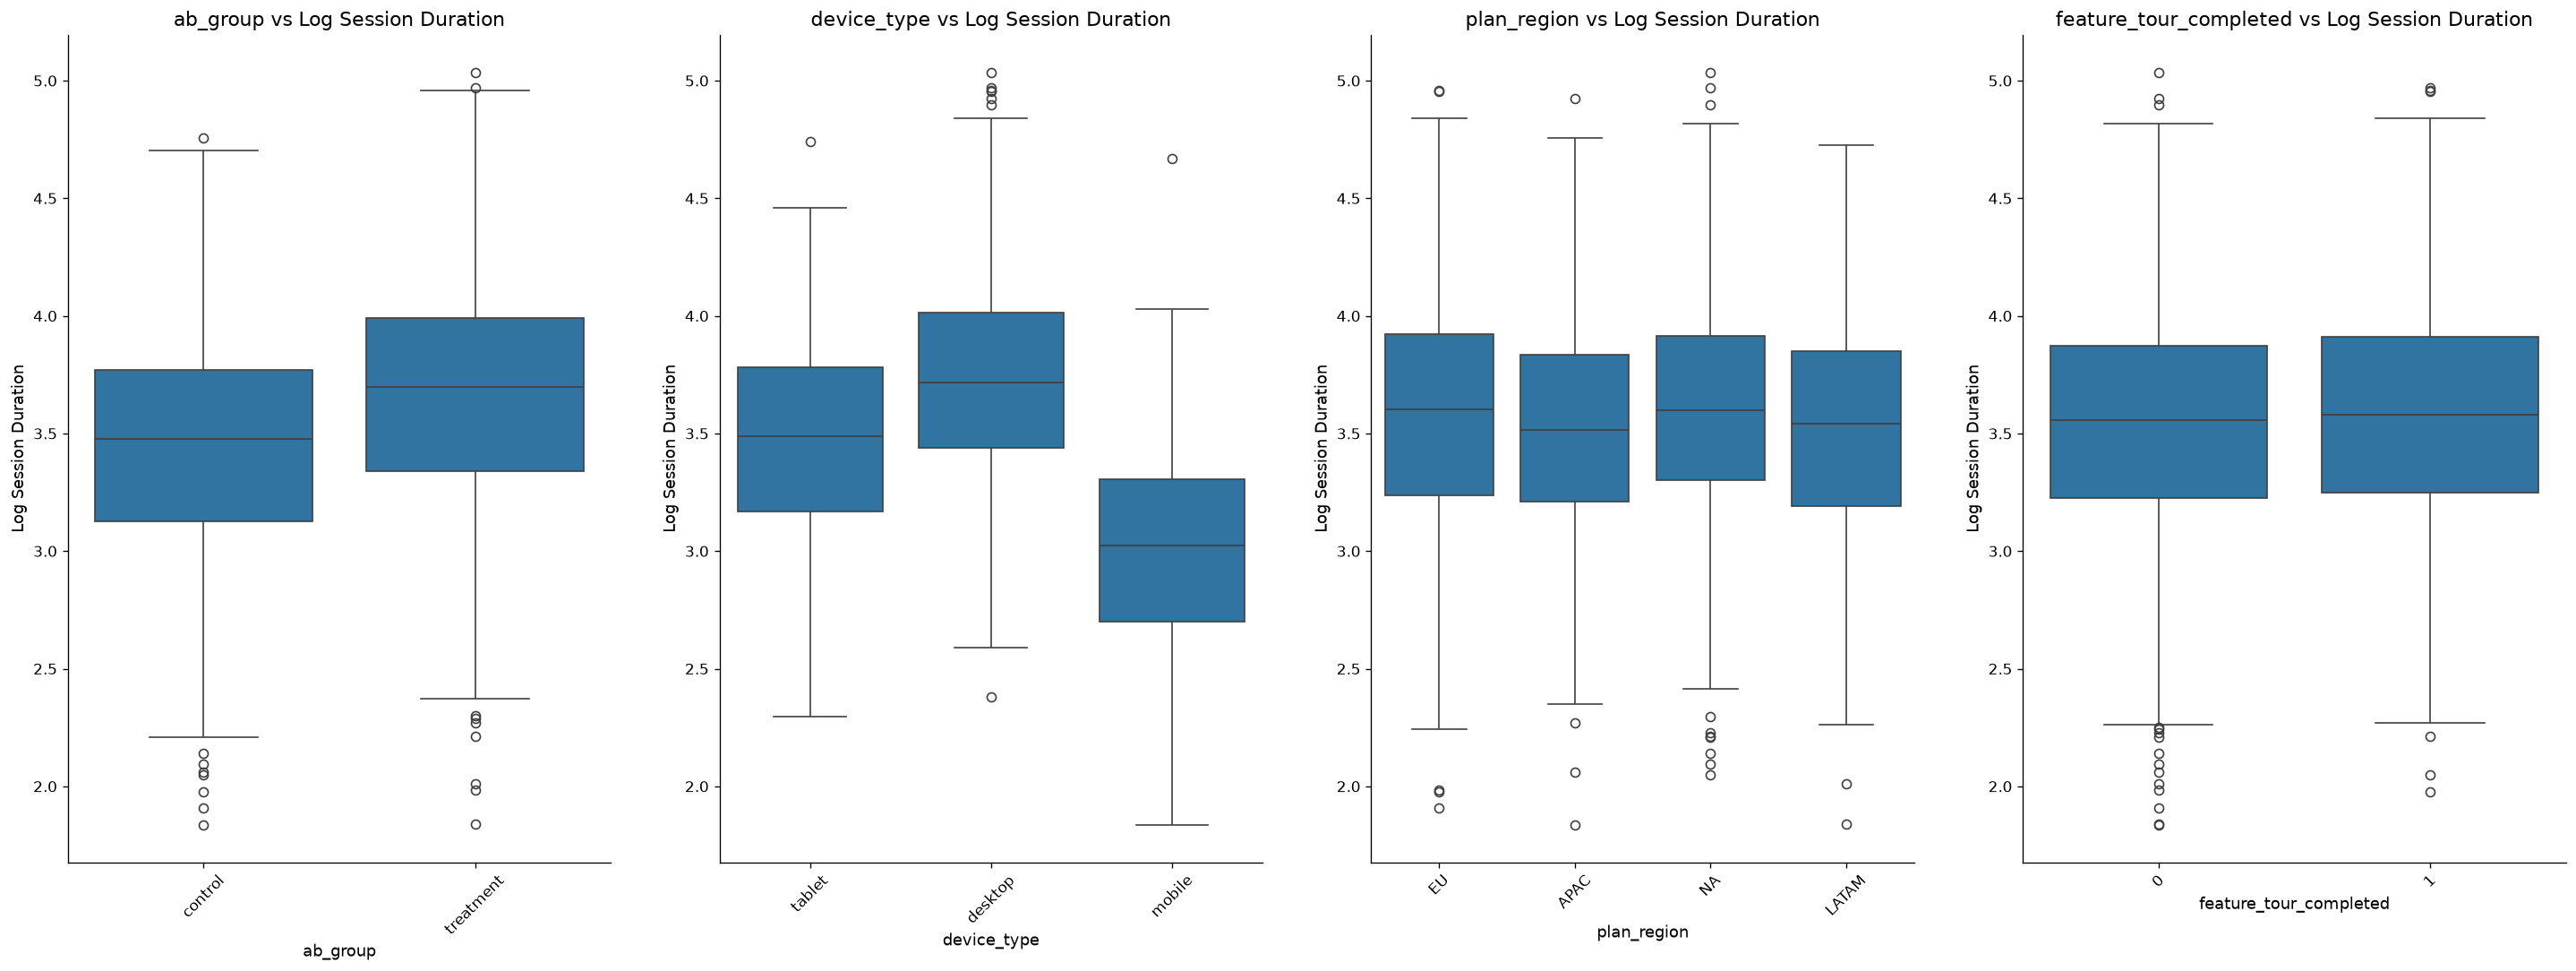

In [8]:
# BEGIN
#     Define list of categorical predictor variables
cat_predictors = ['ab_group', 'device_type', 'plan_region', 'feature_tour_completed']
M = len(cat_predictors) # 4 predictors to analyse

#     Initialize visual grid layout (1 row by M columns, where M is the number of categories)
fig, ax = plt.subplots(1, M, figsize=(30, 10))

#     FOR each categorical variable:
for i, cat_predictor in enumerate(cat_predictors):
#         Retrieve unique category levels
#         Group log-transformed outcome values by category levels   
#         Draw boxplots of log-transformed outcome grouped by category level

# seaborn automatically retrieves unique categories and groups them
    sns.boxplot(data=df_ab, x=cat_predictor, y=wb_session_duration_log, ax=ax[i])

#         Rotate category axis labels for readability
    ax[i].tick_params(axis='x', rotation=45)

#         Label axis and set titles
    ax[i].set_title(f'{cat_predictor} vs Log Session Duration')
    ax[i].set_xlabel(cat_predictor)
    ax[i].set_ylabel('Log Session Duration')
#     END FOR

    # some stats to accurately analyse the plots
    print('Statistics for AI suggestion usage by A/B group:')
    print(df_ab.groupby(cat_predictor)['avg_whiteboard_session_duration_min_log'].describe().round(2))

#     Render layout
plt.show()
# END

**✏️ Your interpretation (A1.3):**

We created histograms to check the skew and frequency of the values of the numerical predictors, and compared the log outcome against them in a scatter plot. By observing these plots and the correlation coefficients, we can see that `prior_whiteboard_sessions`, `num_collaborators` and `templates_used` have weak positive correlation with the log outcome, and all are right-skewed.

It may be worth log transforming `prior_whiteboard_sessions` as it seems to have the highest correlation with the outcome.

However, `account_age_days` does not have any correlation and we can see that there is no pattern in the data comparison from the scatter values on the scatter plot as well. Hence, we will not be including `account_age_days` in our model.

From the box plots of the categorical predictors, we can see that `feature_tour_completed` has roughly the same mean for all of its categories, which symbolizes that this features might not provide any value to predicting the outcome, as there is no visible separation in the results that could help predict the outcome. Hence, we will not be including `feature_tour_completed`.

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [9]:
# BEGIN
#     Load baseline dataset

#     // 1. Encode Categorical Variables
#     Convert experimental group ('ab_group') into a binary integer indicator
df_ab['ab_group_binary'] = (df_ab['ab_group'] == 'treatment').astype(int)

#     Generate dummy indicators (one-hot encoding) for device types, omitting the first category
# drop_first=True -> will manually drop the first column (desktop) as I need it for later sections
df_ab = pd.get_dummies(df_ab, columns=['device_type'], dtype=int) 

#     Generate dummy indicators (one-hot encoding) for regions, omitting the first category
df_ab = pd.get_dummies(df_ab, columns=['plan_region'], dtype=int, drop_first=True)

#     // 2. Perform Optional Transformations
#     Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values
df_ab['prior_whiteboard_sessions_log'] = np.log(df_ab['prior_whiteboard_sessions'] + 1)
df_ab['num_collaborators_log'] = np.log(df_ab['num_collaborators'] + 1)
df_ab['templates_used_log'] = np.log(df_ab['templates_used'] + 1)
print('Columns', df_ab.columns)

#     // 3. Assemble Modeling Dataset
#     Merge numerical characteristics, binary groups, and dummy indicators into matrix X
X = df_ab[[
    # binaries
    'ab_group_binary',

    # dummy indicators
    'device_type_mobile',
    'device_type_tablet', 
    'plan_region_EU',
    'plan_region_LATAM',
    'plan_region_NA',

    # numeric 
    'prior_whiteboard_sessions_log',
    'num_collaborators_log',
    'templates_used_log'
]]

#     Set target vector y as the log-transformed outcome variable
y = wb_session_duration_log

#     // 4. Quality Control
#     Verify that there are no missing (null) values in feature matrix X
print('Missing values:', X.isnull().sum())

#     Inspect matrix dimensions and print a preview of the processed data
print('X shape:', X.shape)
print('X head:', X.head())
# END

Columns Index(['user_id', 'ab_group', 'account_age_days', 'prior_whiteboard_sessions',
       'num_collaborators', 'feature_tour_completed', 'templates_used',
       'ai_suggestions_used', 'whiteboard_actions_per_session',
       'avg_whiteboard_session_duration_min',
       'avg_whiteboard_session_duration_min_log', 'ab_group_binary',
       'device_type_desktop', 'device_type_mobile', 'device_type_tablet',
       'plan_region_EU', 'plan_region_LATAM', 'plan_region_NA',
       'prior_whiteboard_sessions_log', 'num_collaborators_log',
       'templates_used_log'],
      dtype='str')
Missing values: ab_group_binary                  0
device_type_mobile               0
device_type_tablet               0
plan_region_EU                   0
plan_region_LATAM                0
plan_region_NA                   0
prior_whiteboard_sessions_log    0
num_collaborators_log            0
templates_used_log               0
dtype: int64
X shape: (2000, 9)
X head:    ab_group_binary  device_type_mobile 

**✏️ Your interpretation (A2):**

Final features in matrix X are as follows:

**Binaries:**
- `ab_group_binary`: Necessary to see the control (set to 0) and the treatment (set to 1) groups effects on the outcome variable.

**Dummy indicators:**
- `device_type_mobile`, `device_type_tablet`: One-hot encoding was required as `device_type` contained more than 2 categorical values. This is necessary for processing for the model, as it cannot process text. We dropped the first value to prevent multicollinearity. We can see if a specific device allows for longer whiteboard sessions, like desktop, or can see if mobile limits whiteboard interactions.
- `plan_region_EU`, `plan_region_LATAM`, `plan_region_NA`: One-hot encoding was required as `plan_region` contained more than 2 categorical values. This is necessary for processing for the model, as it cannot process text. We dropped the first value to prevent multicollinearity. We can see if a different region might lead to longer sessions, as different regions have different work ethics, different work requirements etc.

**Numeric:**
- `prior_whiteboard_sessions_log`: Log transformed from `prior_whiteboard_sessions` as it was right-skewed. Necessary to see the effect `prior_whiteboard_sessions` have on the outcome variable. Previous behaviour can help us predict future behaviour, in sense that users spending less time on the whiteboard, are likely to keep spending less time unless some other actor (ai) affects it.
- `num_collaborators`: Necessary to see if more collaborators can lead to higher session duration times.
- `templates_used`: Necessary to see if using a heigher number of templates leads to higher session duration times.

### A3 — OLS Regression


In [10]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.366
Model:                                             OLS   Adj. R-squared:                  0.363
Method:                                  Least Squares   F-statistic:                     127.4
Date:                                 Thu, 25 Jun 2026   Prob (F-statistic):          1.81e-189
Time:                                         16:45:39   Log-Likelihood:                -1016.4
No. Observations:                                 2000   AIC:                             2053.
Df Residuals:                                     1990   BIC:                             2109.
Df Model:                                            9                                         
Covariance Type:                             nonrobust                                         
                                    coef

#### A3.1 — Interpret the model

In [11]:
# BEGIN
#     Input trained OLS regression model
#     Input experimental dataframe

#     // 1. Evaluate Model Fit
#     Display model's R-squared value to assess variance explained
print(f'R-squared: {model_ols.rsquared:.4f}')

#     // 2. Analyze Treatment Effect
#     Extract coefficient and significance (p-value) for the A/B testing variable
ab_coef = model_ols.params['ab_group_binary']
ab_pval = model_ols.pvalues['ab_group_binary']

print(f'Coefficient for the A/B testing variable: {ab_coef:.4f}')
print(f'Significance (p-value) for the A/B testing variable: {ab_pval:.4f}')

#     Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
## for increase, do -1 or -100%
time_change = (np.exp(ab_coef) - 1)
print(f'Change in time for treatment group vs control: {time_change:.2f}')

#     Display treatment effect size and statistical significance
avg_duration_mean = df_ab['avg_whiteboard_session_duration_min'].mean()
duration_change  = (avg_duration_mean * time_change)
print(f'Mean duration: {avg_duration_mean:.1f}mins')
print(f'Approximate change in minutes for treatment group vs control: {duration_change:.1f}mins')

#     // 3. Extract Significant Predictors
#     Filter all model coefficients where p-value < 0.05
sig_coefs = model_ols.params[model_ols.pvalues < 0.05].index

#     FOR each significant variable:
for sig_coef in sig_coefs:
#         Display variable name, its directional coefficient, and its p-value
    coefficient = model_ols.params[sig_coef]
    p_value = model_ols.pvalues[sig_coef]
    print(f'Display name: {sig_coef} | coefficient: {coefficient:.4f} | p-value: {p_value:.4f}')
#     END FOR
# END

R-squared: 0.3656
Coefficient for the A/B testing variable: 0.1764
Significance (p-value) for the A/B testing variable: 0.0000
Change in time for treatment group vs control: 0.19
Mean duration: 39.5mins
Approximate change in minutes for treatment group vs control: 7.6mins
Display name: const | coefficient: 3.2029 | p-value: 0.0000
Display name: ab_group_binary | coefficient: 0.1764 | p-value: 0.0000
Display name: device_type_mobile | coefficient: -0.7230 | p-value: 0.0000
Display name: device_type_tablet | coefficient: -0.2550 | p-value: 0.0000
Display name: plan_region_EU | coefficient: 0.0764 | p-value: 0.0018
Display name: plan_region_NA | coefficient: 0.0846 | p-value: 0.0004
Display name: prior_whiteboard_sessions_log | coefficient: 0.1408 | p-value: 0.0000
Display name: num_collaborators_log | coefficient: 0.0881 | p-value: 0.0000
Display name: templates_used_log | coefficient: 0.0795 | p-value: 0.0000


**✏️ Results paragraph (A3):**

The treatment effect estimate for the average whiteboard session duration is approximately 19%. Meaning that treatment groups (with the use of the AI support tool) saw an increase in usage time by nearly 19%, which is an increase of 7.6 minutes for an average session duration.

The R² value is 0.3656, which tells us that nearly 36.6% of the variation in the outcome can be explained by the model. So the predictors we have used in the model have about 36.6% affect in the outcome.

The interesting predictors are `device_type` and `prior_whiteboard_sessions_log`. The device type predictors have the largest negative coefficients for `tablet` and `mobile` and p-value < 0.01, which means that users with tablets or mobiles have shorter average durations per session. The `prior_whiteboard_sessions_log` predictor has a coefficient of 0.1408 and p-value < 0.01, which indicates that having had prior sessions on phigma positively impacts user session duration, and increases it.

Hence, overall we can see that the AI assistant's effect can be considered to be practically meaningful, not just statistically significant.


#### A3.2 — Regression diagnostics

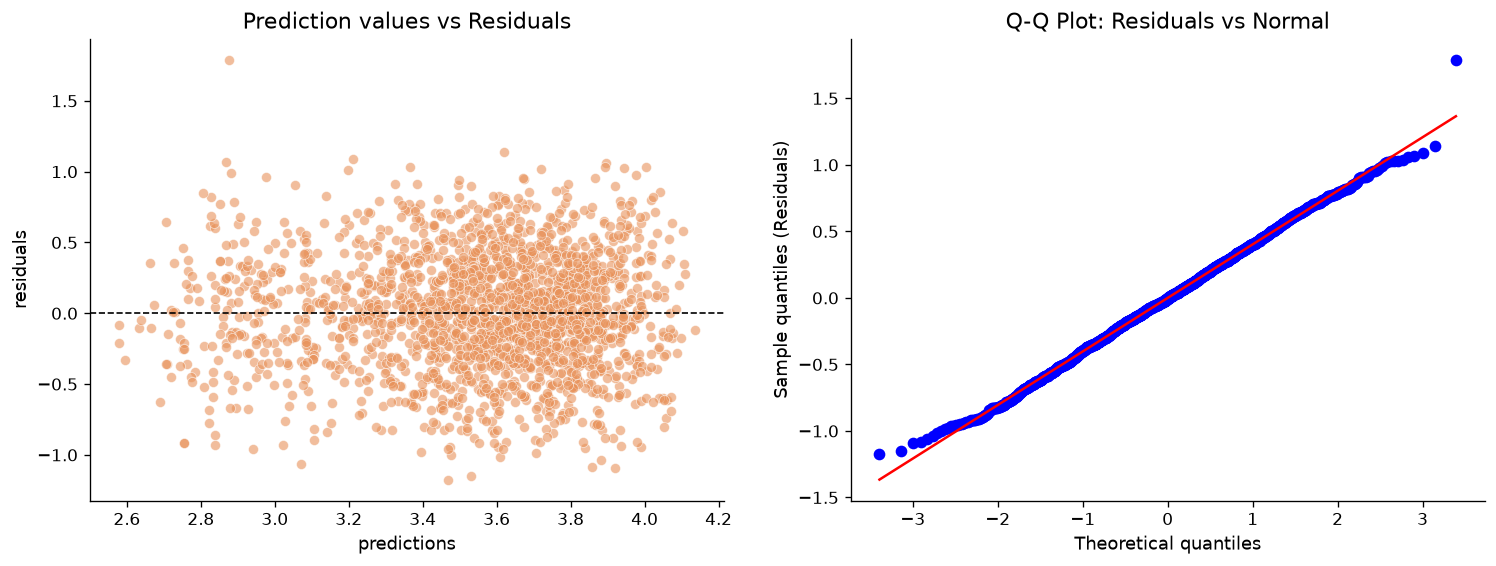

In [12]:
# BEGIN
#     Extract predictions and error terms (residuals) from regression model
predictions = model_ols.fittedvalues
residuals = model_ols.resid

#     Initialize a side-by-side diagnostic visualization layout
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

#     // Check for uniform variance (homoscedasticity)
#     Draw scatter plot of prediction values vs residuals
sns.scatterplot(
    x=predictions,
    y=residuals,
    alpha=0.6,
    ax=ax[0],
    legend=True,
    color=ACCENT
)
ax[0].set_title('Prediction values vs Residuals')
ax[0].set_xlabel('predictions')
ax[0].set_ylabel('residuals')

#     Overlay a horizontal zero-error baseline reference line
ax[0].axhline(0, color='black', linewidth=1, linestyle='--')

#     // Check for normality of errors
#     Draw a Q-Q plot of residuals against a normal theoretical distribution
stats.probplot(residuals, dist='norm', plot=ax[1])
ax[1].set_title('Q-Q Plot: Residuals vs Normal')
ax[1].set_xlabel('Theoretical quantiles')
ax[1].set_ylabel('Sample quantiles (Residuals)')

#     Render diagnostic plots
plt.show()
# END

**✏️ Your interpretation (A3.2):**

The scatterplot shows that the values are randomly scattered around 0, with more values concentrated to the right of the plot. This somewhat supports homoscedasticity, that the values are spread uniformly around the zero-error line, and have a uniform variance. However, the heavy clustering around the right side of the plot means that our model seems to be more optimized for this cluster, rather than the light clustering, which could result in inaccurate predictions for values in the light clustering area, but accurate ones for the heavy clustering values.

The Q-Q plot suggests normally distributed errors, even though there are some discrepencies at the starting and ending points of the line, which are not plotted on the line itself. However, majority of the errors are normally distributed as can be seen above.


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

We will be testing the following two variables:

- `ab_group` and `device_type` 

We are expecting that AI suggestions matter more, and are used more on the desktop, where there is more screen space, and easier navigation of tools, in the sense that you have a keyboard, and a mouse to navigate the phigma whiteboard, while on a mobile or tablet, you have less screen space and less friendly navigation abilities when it comes to a whiteboard.

The groups with desktops will likely show larger session durations as they are more likely to stay engaged for longer when they have a larger, accesible and user-friendly workspace as opposed to mobile or tablet users who might end sessions early due to frustration with controlling the smaller interfaces.


In [13]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']
df_ab['ab_x_device_desktop'] = df_ab['ab_group_binary'] * df_ab['device_type_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
X_interact = pd.concat([X_const, df_ab['ab_x_device_desktop']], axis=1)
model_interact = sm.OLS(y, X_interact).fit()
print(model_interact.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.366
Model:                                             OLS   Adj. R-squared:                  0.363
Method:                                  Least Squares   F-statistic:                     115.0
Date:                                 Thu, 25 Jun 2026   Prob (F-statistic):          7.06e-189
Time:                                         16:45:39   Log-Likelihood:                -1015.3
No. Observations:                                 2000   AIC:                             2053.
Df Residuals:                                     1989   BIC:                             2114.
Df Model:                                           10                                         
Covariance Type:                             nonrobust                                         
                                    coef

Interaction coefficient for ab groups and desktop devices: 0.0548
P-value for ab groups and desktop devices: 0.1381


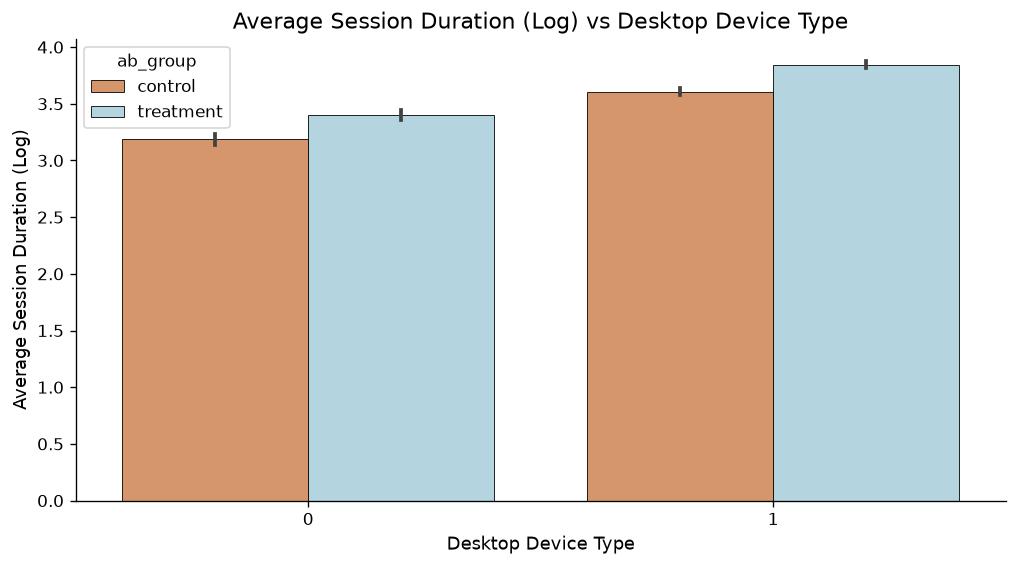

In [14]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_ab,
    x='device_type_desktop', 
    y='avg_whiteboard_session_duration_min_log',
    hue='ab_group', 
    ax=ax, 
    palette=[ACCENT, 'lightblue'],
    edgecolor='black', 
    linewidth=0.5,
    legend=True
)
ax.set_title('Average Session Duration (Log) vs Desktop Device Type')
ax.set_xlabel('Desktop Device Type')
ax.set_ylabel('Average Session Duration (Log)')

# get the interaction coefficient for analysis
inter_coef = model_interact.params['ab_x_device_desktop']
inter_pval = model_interact.pvalues['ab_x_device_desktop']
print(f'Interaction coefficient for ab groups and desktop devices: {inter_coef:.4f}')
print(f'P-value for ab groups and desktop devices: {inter_pval:.4f}')


**✏️ Your interpretation (A4):**

Based on the grouped bar graph above, we can see that users who had a desktop device type (1) had longer whiteboard session durations on average than users who do not have the desktop device type (0, they have mobiles or tablets) instead. This proves that our theory about accessible and larger workspaces is indeed true, as it seems to keep them engaged for longer when it is easier to work and interact with the dashboard on a larger screen, probably with a keyboard and a mouse for navigation.

From the treatment group values, we can also that having a desktop leads to an increase in engagement time, and users with desktops will benefit more from the AI assistant. For the phigma marketing and development team, it would be better for them to first rollout the desktop version / features for the AI assistant so people can benefit from it more, and then rollout the features for mobile and tablet, and perhaps also conduct a user study to understand how to make the mobile and tablet AI-assisted versions more accesible and user-friendly for their users.

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [15]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [16]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [17]:
# YOUR CODE HERE

# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
def calculate_avg_duration(row):
    # if no number of sessions, set the average to zero as well
    if row['num_sessions_30d'] == 0:
        return 0
    return row['total_time_min_30d'] / row['num_sessions_30d']

df_sub['avg_session_duration_min'] = df_sub.apply(
    calculate_avg_duration,
    axis=1
)

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True, dtype=int)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True, dtype=int)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)
df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed

X_sub = pd.concat([
    df_sub[[
        # existing cols
        'num_sessions_30d',
        'projects_created_30d',
        'exports_30d',
        'collaborators_invited_30d',
        'support_tickets_30d',
        'used_premium_feature_preview',
        'ai_assistant_sessions_30d',
        # features
        'days_to_first_session',
        'avg_session_duration_min',
        'is_weekend_signup',
        'country_tier_enc',
    ]],
    device_dummies2,
    referral_dummies,
], axis=1)

y_sub = df_sub['subscribed']

# Confirm
print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
X_sub.head(3)


Any inf: False
Any NaN: False
Feature matrix shape: (3000, 16)


,num_sessions_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1,1,0,0,0,1,6,5,96.0000,0,1,0,1,0,0,0
1,15,8,1,5,0,0,0,0,17.8000,0,2,0,1,0,0,1
2,16,0,0,3,3,1,4,14,16.4375,0,1,0,0,0,0,0


**✏️ Your interpretation (B1):**

**Engineered Features**

1. `days_to_first_session`: This might be able to tell us if the user delaying their first session might result in less subscriptions, as users may not be interested in the app or its services.
2. `avg_session_duration_min`: This might be able to tell us that if a user spends more average time using the app, they may be more likely to subscribe since they are interested in, and find the app useful.
3. `is_weekend_signup`: This might be able to tell us if a user is using the app for themselves, as in personal, more casual use, and not work use, which might lead to less subscriptions since they might not need to work on the app extensively or would require to have a subscription for that usage.
4. `country_tier_enc`: This might be able to tell us that if a country belongs to a certain tier, it may be more likely to have subscriptions to the app, eg, tier1 countries might subscribe more due to more demand of this tool in their market.
5. `device_dummies2`: This might be able to tell us what device might make a user want to subscribe to the tool, like desktop might be easier to navigate, hence desktop users might subscribe more.
6. `referral_dummies`: This might be able to tell us what referral type has resulted in higher subscription rates, like a `referral` by a friend or collegue might make a user trust the app more and hence lead to subscriptions.

**Divide By Zero Edge Case**

For the divide-by-zero edge case, we set values of `avg_session_duration_min` to zero where `num_sessions_30d` is zero, manually using a named function `calculate_avg_duration` and `df.apply`. We do this because dividing by zero would return undefined, and it makes sense to set the average to 0 because the total number of sessions are 0, hence no duration minutes are available.


### B2 — EDA for Subscription


In [18]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")

Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


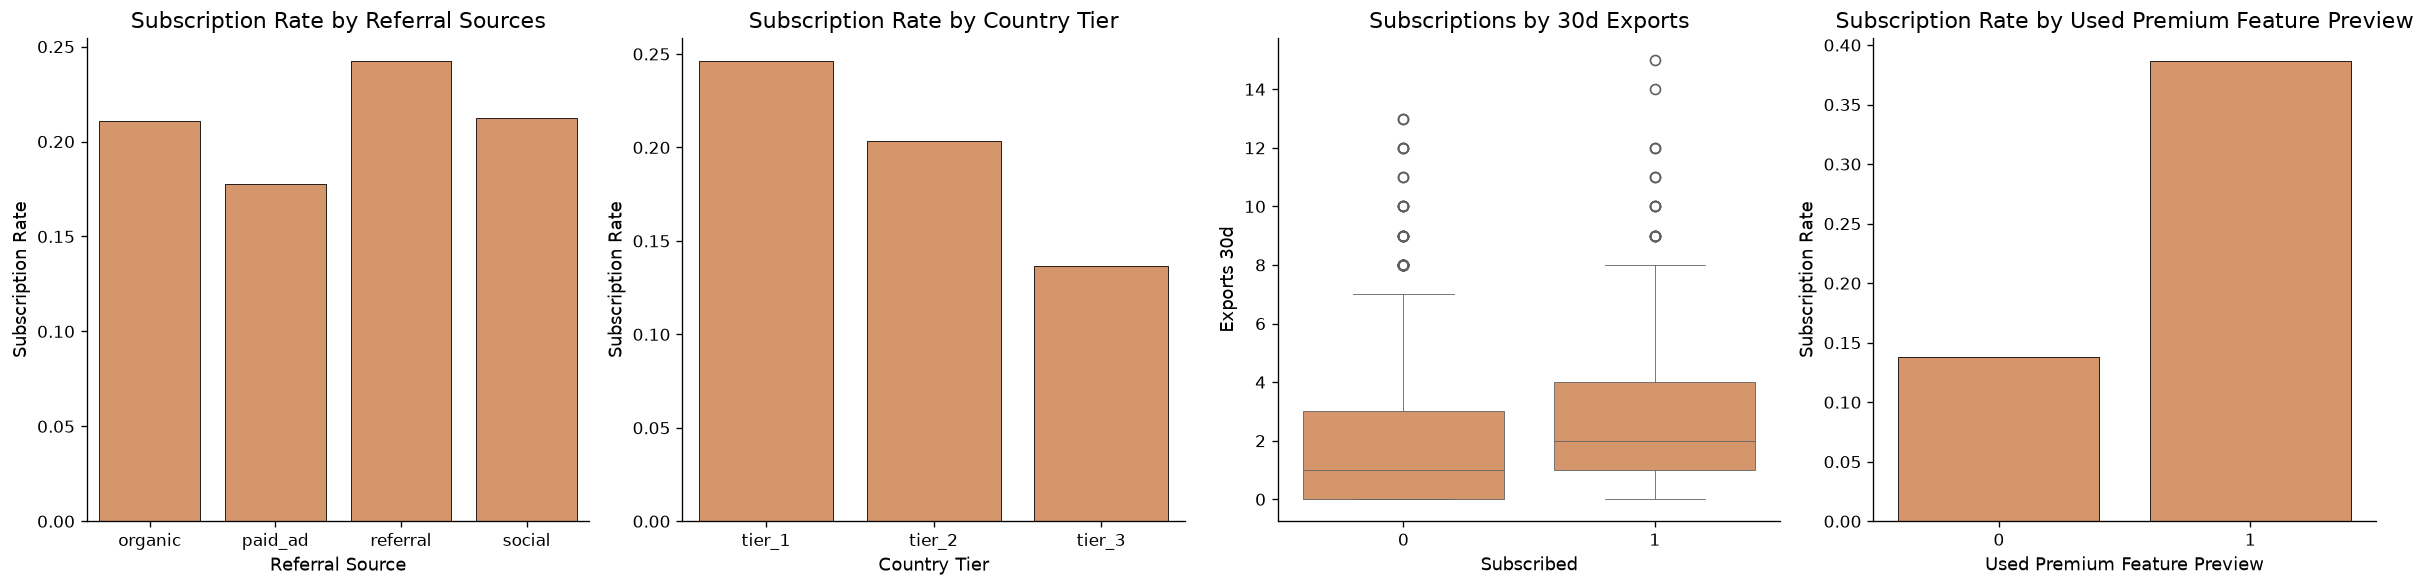

In [19]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot 1 — Bar chart: subscription rate by referral_source
referral_rate = df_sub.groupby('referral_source')['subscribed'].mean()
sns.barplot(
    x=referral_rate.index, 
    y=referral_rate.values,
    ax=axes[0], 
    color=ACCENT,
    edgecolor='black',
    linewidth=0.5,
)
axes[0].set_title('Subscription Rate by Referral Sources')
axes[0].set_xlabel('Referral Source')
axes[0].set_ylabel('Subscription Rate')

# Plot 2 — Bar chart: subscription rate by country_tier
country_rate = df_sub.groupby('country_tier')['subscribed'].mean()
sns.barplot(
    x=country_rate.index, 
    y=country_rate.values,
    ax=axes[1], 
    color=ACCENT,
    edgecolor='black',
    linewidth=0.5,
)
axes[1].set_title('Subscription Rate by Country Tier')
axes[1].set_xlabel('Country Tier')
axes[1].set_ylabel('Subscription Rate')

# Plot 3 — Boxplot: exports_30d distribution by subscribed (0 vs 1)
sns.boxplot(
    data=df_sub,
    x='subscribed', 
    y='exports_30d',
    ax=axes[2],
    color=ACCENT,
    linewidth=0.5,
)
axes[2].set_title('Subscriptions by 30d Exports')
axes[2].set_xlabel('Subscribed')
axes[2].set_ylabel('Exports 30d')

# Plot 4 - Bar chart: subscription rate by used_premium_feature_preview
premium_rate = df_sub.groupby('used_premium_feature_preview')['subscribed'].mean()
sns.barplot(
    x=premium_rate.index, 
    y=premium_rate.values,
    ax=axes[3], 
    color=ACCENT,
    edgecolor='black',
    linewidth=0.5,
)
axes[3].set_title('Subscription Rate by Used Premium Feature Preview')
axes[3].set_xlabel('Used Premium Feature Preview')
axes[3].set_ylabel('Subscription Rate')

plt.tight_layout()
plt.show()


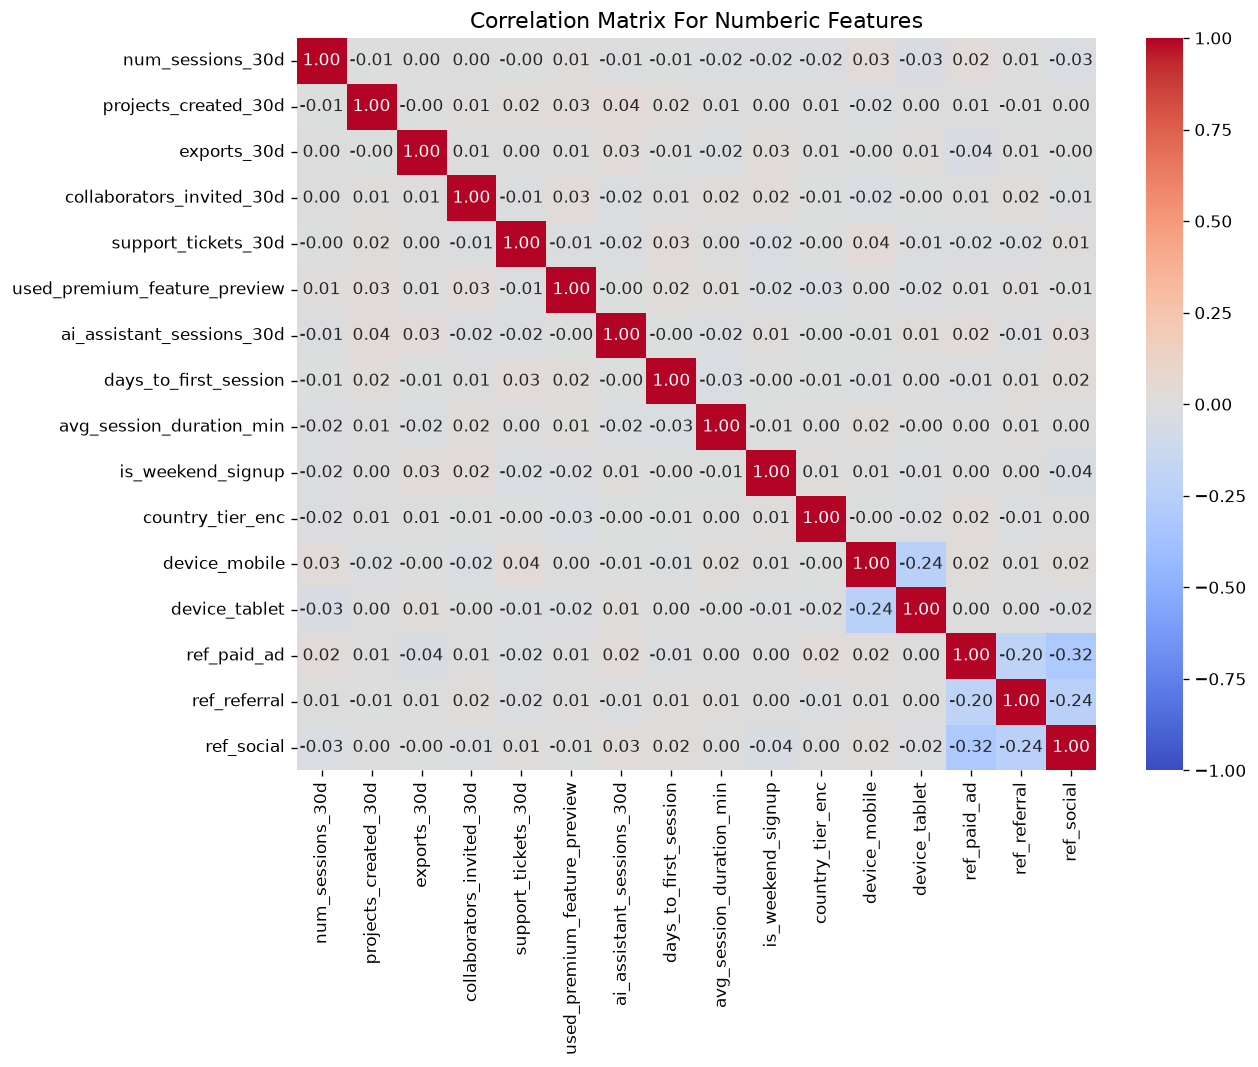

In [20]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
corr = X_sub[numeric_features].corr()

# Plot as heatmap
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    ax=ax,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
ax.set_title('Correlation Matrix For Numberic Features', fontsize=13)
plt.tight_layout()
plt.show()

**✏️ Your interpretation (B2):**

We can see from the analysis that:

1. `used_premium_feature_preview` has the higher number of subscriptions, which shows that people who have used the premium features are more likely to subscribe for it.
2. `country_tier`: we predicted that tier1 countries would be more likely to have more subscriptions, and that can be seen by the bar plots we created for subscription rate by country tiers. Most subscriptiosn are by tier1 countries (strong correlation), followed by tier2, then tier3.
3. `referral_source`: The referral source `referral` is strongly correlated with subscriptions, as we can see from the bar plot that the heigher number of users who subscribe have been using the app through `referral`s.
4. `exports_30d`: We can see from the box plot that users who have higher number of exports are more likely to subscribe, which may be because their work woudl require premium features and they are using the app more.

The correlation matrix between the numeric features of the dataset shows us that there are no two strongly correlated features. We have `ref_social` and `ref_paid_ad` having a negative correlation of 0.32, which is a weak correlation. This is good as there is no multicollinearity, and hence we can see the individual impact of each of the features on the subscription outcome.

### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [21]:
# YOUR CODE HERE
X_const_sub = sm.add_constant(X_sub)
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.440669
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2983
Method:                           MLE   Df Model:                           16
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.1389
Time:                        16:45:40   Log-Likelihood:                -1322.0
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 1.039e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.3413      0.259     -9.036      0.000

In [22]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
p = model_logit.pvalues

odds_ratios = np.exp(model_logit.params[p < 0.05])
conf_int = np.exp(model_logit.conf_int()[p < 0.05])

# Combine into a readable table and display
# Filter to significant only: p < 0.05
table = pd.DataFrame({
    'Odds Ratio': odds_ratios.round(2),
    'Lower Conf Int': conf_int[0].round(2),
    'Upper Conf Int': conf_int[1].round(2),
}).sort_values('Odds Ratio', ascending=True)

print('Odd ratios for significant predictors (p < 0.05):')
print(table)


Odd ratios for significant predictors (p < 0.05):
                              Odds Ratio  Lower Conf Int  Upper Conf Int
const                               0.10            0.06            0.16
country_tier_enc                    0.70            0.62            0.80
days_to_first_session               0.91            0.89            0.94
avg_session_duration_min            1.02            1.01            1.04
collaborators_invited_30d           1.06            1.02            1.11
support_tickets_30d                 1.17            1.07            1.27
exports_30d                         1.21            1.16            1.27
used_premium_feature_preview        4.34            3.57            5.28


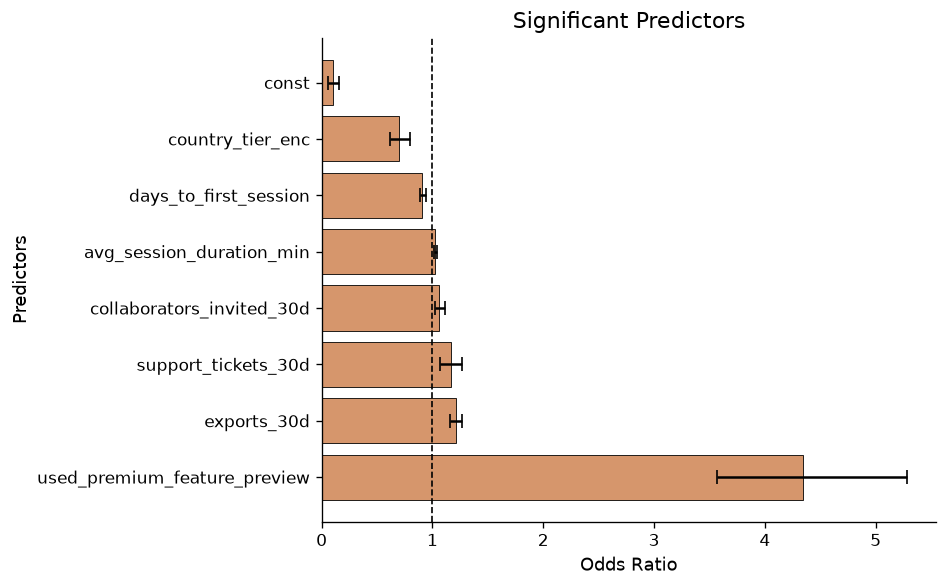

In [23]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=table,
    x='Odds Ratio',
    y=table.index,
    color=ACCENT,
    edgecolor='black', 
    linewidth=0.5,
    ax=ax
)

lower_error = table['Odds Ratio'] - table['Lower Conf Int']
upper_error = table['Upper Conf Int'] - table['Odds Ratio']

ax.errorbar(
    x=table['Odds Ratio'],
    y=range(len(table)),
    xerr=[lower_error, upper_error],
    fmt='none',
    color='black',
    capsize=4
)

ax.axvline(1, color='black', linewidth=1, linestyle='--')

ax.set_xlabel('Odds Ratio')
ax.set_ylabel('Predictors')
ax.set_title('Significant Predictors')

plt.tight_layout()
plt.show()


**✏️ Results paragraph (B3):**

Setting the reference line to 1, as OR = 1.0 means no effect, and OR > 1.0 means increased odds.

1. `used_premium_feature_preview`: We can see that the odds ratio for previous exposure to premium feature to result in a subscription is 4.34 which means that users are more than 4 times likely to subscribe if they have used the premium feature preview. This is consistent with that we have predicted though I did not expect the subscription conversion rate to be this huge for this feature.
2. `exports_30d`: We can see that the odds ratio for the number of exports of a user is 1.21, which means with a higher number of exports, they are more likely to subscribe. This is as we predicted.
3. `days_to_first_session`: We can see that the odds ratio for days to first session is 0.91, which means that users who delay having their first session (more number of days to first session) will have a lower likely hood of subscribing. Hence we can say that if the user starts using the app earlier (has more time with it), they will be more likely to subscribe, which is as we predicted.

What I sound surprising was that `support_tickets_30d` has an increased odds ratio of 1.17, which is kind of weird because submitting more support tickets might mean they are frustrated with the app, or cannot navigate it, or maybe it currently doesn't meet their needs. Maybe more support tickets mean more likely subscription because the customer service and dev team is very helpful and responsive, or that people are more engaged with the app and hence submit support tickets and end up learning about and liking the app features more.

And the `average_session_duration_min` odds ratio is 1.02, which is also surprising. I had expected it to be higher than this, but it seems that average session duration might not have too much of an effect on subscriptions. This might be because more time spent doesn't necessarily mean a user will subscribe, it might just be their work is different, or that they can complete or spend time on it without premium features.


### B4 — Logistic Regression with sklearn (Predictive)


In [24]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


Train: (2400, 16)  |  Test: (600, 16)
Train positive rate: 0.208  |  Test positive rate: 0.208


In [25]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


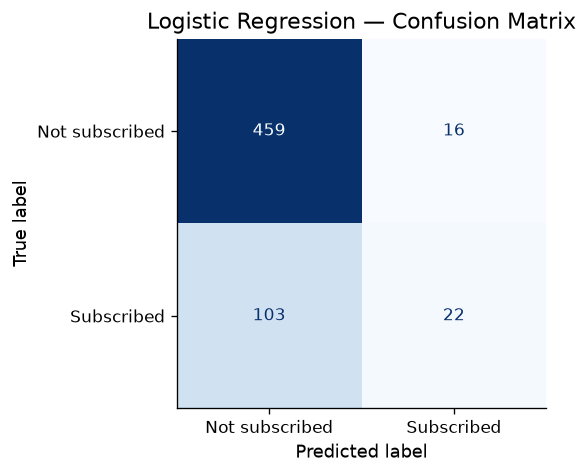

In [26]:
# YOUR CODE HERE
# Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()


In [27]:
# YOUR CODE HERE
# Classification report
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.58      0.18      0.27       125

      accuracy                           0.80       600
     macro avg       0.70      0.57      0.58       600
  weighted avg       0.77      0.80      0.76       600

ROC-AUC: 0.7374


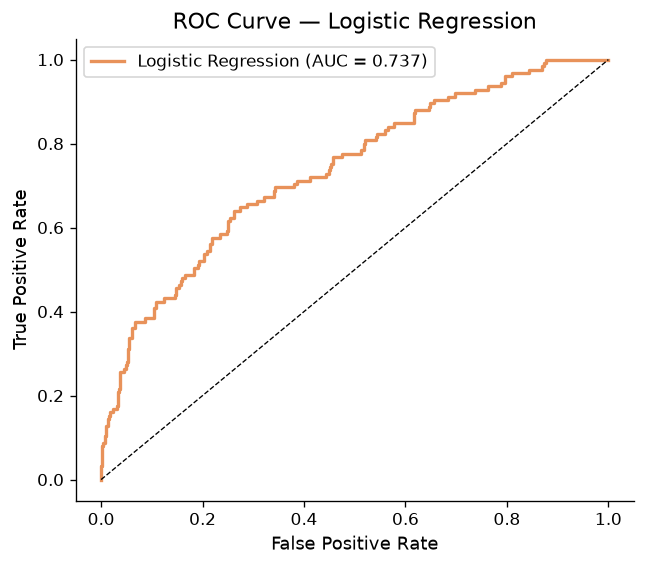

In [28]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()


**✏️ Your interpretation (B4):**

Due to the class imbalance in our data (475 non-subscribed vs 125 subscribed), we can see that we are getting unreliable values for the models accuracy. For example, if the model predicted all 600 values as non-subscribed, it would still have a good accurage of (475/600 = 0.79), nearly 80%. Hence, recall would be a better metric for testing the model. 

We can see that the recall for the subscribed value predictions is 0.18, which means the model is effectively missing 82% of actual people who have the potential to subscribe. It produces 103 false negatives for subscribers out of a total of 125.

For phigma, the model missing these many users who has the potential to subscribe is very costly to the company as they are losing around 82% of potential revenue through these subscriptions. Having able to predict these users accurately would help Phigma in being able to target these users, maybe send them promotional emails and help them be more inclined to subscribe.

---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `Random Forest`

**Conceptual explanation:**
[https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/,

https://www.geeksforgeeks.org/machine-learning/logistic-regression-vs-random-forest-classifier/]

Random Forest Classifier uses many decision trees to make classification predictions. The algorithm operates in such a way that the many trees are created from random aspects of the data, which the model splits and then trains on. As it uses random parts of the data, each tree is different. When building these trees it does not look at all the features at once. It picks a few random to build the tree on. Using this random data helps with reducing overfitting. The result of the classification is the answer that most decision trees have given. Hence, it handles missing data well, can better handle not overfitting the data, and may have higher accuracy with larger number of decision trees.

It's different from logistic regression as it uses multiple decision trees for random parts of the features to come to a decision, while regression usually uses log-transformed values of our features to predict an answer and considers a linear relationship between the predictors and the outcome. Random forest also handles imbalanced, partial, high-dimensional data better. For our dataset, the random forest classifier might perform just like our logistic regression model, given that our data set is complete, and our predictors have somewhat linear relationships with the outcome. It might work better with the class imbalance between subscribed and not subscribed.


### C2 — Fit and Evaluate


In [29]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
clf_c = RandomForestClassifier(random_state=42)   # add random_state if supported
clf_c.fit(X_train, y_train)
y_pred_c = clf_c.predict(X_test)
y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


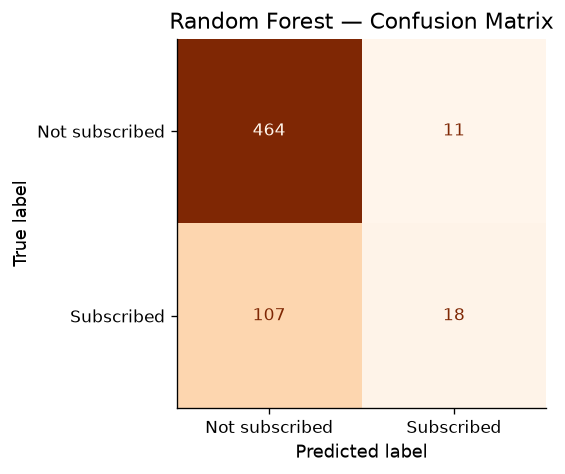

In [30]:
# YOUR CODE HERE
# Confusion matrix
cm_c = confusion_matrix(y_test, y_pred_c)
disp_c = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=['Not subscribed', 'Subscribed'])

fig, ax = plt.subplots(figsize=(5, 4))
disp_c.plot(ax=ax, cmap='Oranges', colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [31]:
# YOUR CODE HERE
# Classification report + ROC-AUC
print(classification_report(y_test, y_pred_c, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c):.4f}")

                precision    recall  f1-score   support

Not subscribed       0.81      0.98      0.89       475
    Subscribed       0.62      0.14      0.23       125

      accuracy                           0.80       600
     macro avg       0.72      0.56      0.56       600
  weighted avg       0.77      0.80      0.75       600

ROC-AUC: 0.6813


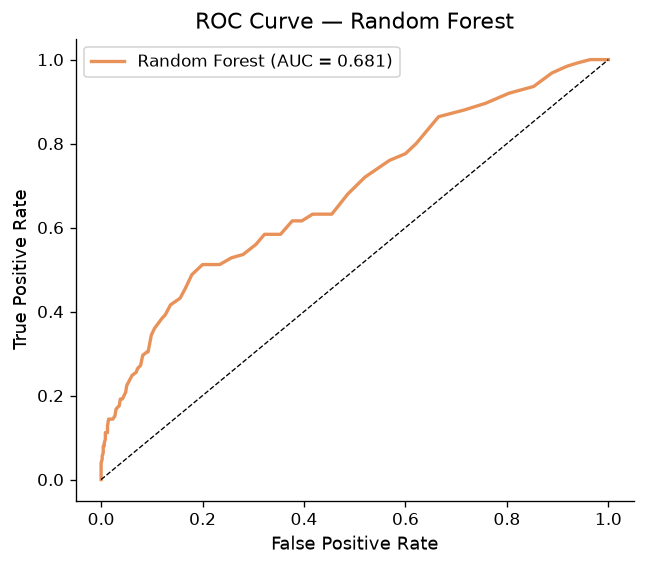

In [32]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
auc_c = roc_auc_score(y_test, y_prob_c)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_c, tpr_c, color=ACCENT, lw=2, label=f'Random Forest (AUC = {auc_c:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest')
ax.legend()
plt.show()

### C3 — Model Comparison


In [33]:
# YOUR CODE HERE
# Summary comparison table
report_lr = classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed'], output_dict=True)
report_c = classification_report(y_test, y_pred_c, target_names=['Not subscribed', 'Subscribed'], output_dict=True)

metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [auc_lr, auc_c],
    'F1 (class 1)': [report_lr['Subscribed']['f1-score'], report_c['Subscribed']['f1-score']],
    'Precision (class 1)': [report_lr['Subscribed']['precision'], report_c['Subscribed']['precision']],
    'Recall (class 1)': [report_lr['Subscribed']['recall'], report_c['Subscribed']['recall']],
}
pd.DataFrame(metrics).set_index('Model').round(4)


,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7374,0.2699,0.5789,0.176
Random Forest,0.6813,0.2338,0.6207,0.144


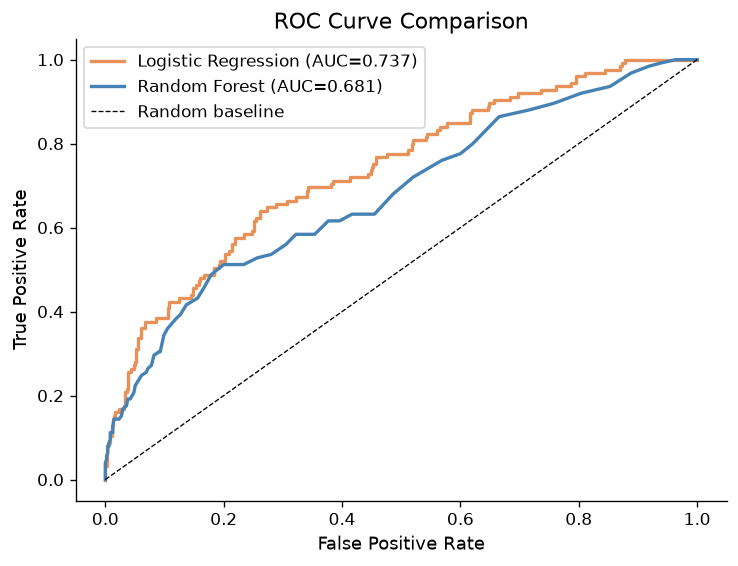

In [34]:
# YOUR CODE HERE
# Dual ROC curve plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'Random Forest (AUC={auc_c:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()


**✏️ Comparison paragraph (C3):**

Logistic Regression	perfomed better than the Random Forest with 0.7374 vs 0.6813 ROC-AUC, which is a performance metric for evaluating binary classification models in machine learning. The logistic regression model classifies better than the random forest. The f1-score and recall (0.14 - 0.18) for class 1 was similar for both models, which means that both models are not doing well at classifying actual subscribers as subscribers. However, precision for Random Forest (0.62) is slightly higher than Logistic Regression (0.58) which means the random forest is slightly better at classifying true subscribers than the logistic model.

This difference could be because random forest using its default parameters (num of trees / predictors, max depth etc) is not able to classify our data correctly. Our data is also complete and somewhat linear, and random forest better handles non-linear, complex and partial data. Without the right parameters on this dataset, the random forest might also just be overfitting into the data.

### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [35]:
# YOUR CODE HERE (BONUS)
# Reference (I read up on hyperparameter tuning from here): https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
# and https://scikit-learn.org/stable/modules/grid_search.html
# and https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [10, 15, 20, 25],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]
}

# Run cross-validated search on the TRAINING SET ONLY
search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
y_pred_tuned = search.best_estimator_.predict(X_test)
y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Default test AUC:{auc_c:.4f}")

print("Did tuning meaningfully improve results? It improved the results as changing these params (mostly max_depth and min_samples_leaf) has helped with reducing overfitting.")


Best parameters: {'bootstrap': False, 'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 100}
Best CV AUC:     0.7356
Tuned test AUC:  0.7013
Default test AUC:0.6813
Did tuning meaningfully improve results? It improved the results as changing these params (mostly max_depth and min_samples_leaf) has helped with reducing overfitting.


---

## Submission Checklist

Before submitting, confirm:

- [x] All `# YOUR CODE HERE` cells are completed and run without errors
- [x] All `**✏️ Your interpretation**` cells contain your own written analysis
- [x] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [x] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [x] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [x] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
